# Before starting...

⚠️ We advise against running this on kaggle directly, but instead downloading the notebooks to your system as training each model take several hours and you will need to download and re-upload your dataset.

This notebook is aimed at creating a dummy submission to participate in the MultiOrg competition!

## 1. Install mmdetection package and dependencies

In [ ]:
!pip install -U openmim
!mim install mmengine
!mim install "mmcv>=2.0.0rc4, <2.2.0"

!git clone https://github.com/open-mmlab/mmdetection.git
!pip install -v -e ./mmdetection

## 2. Import libraries and set paths

In [20]:
import os
from urllib.request import urlretrieve
#from tqdm import tqdm

import numpy as np 
import pandas as pd 
from skimage.io import imread
from skimage.transform import rescale
from skimage.color import gray2rgb

import torch
from torchvision.ops import nms
from mmdet.apis import DetInferencer

# a list of the available config files used in our benchmark
MODELS = {
    "faster r-cnn": {"filename": "faster-rcnn_r50_fpn_organoid_best_coco_bbox_mAP_epoch_68.pth", "source": "https://zenodo.org/records/11388549/files/faster-rcnn_r50_fpn_organoid_best_coco_bbox_mAP_epoch_68.pth"},
    "ssd": {"filename": "ssd_organoid_best_coco_bbox_mAP_epoch_86.pth", "source": "https://zenodo.org/records/11388549/files/ssd_organoid_best_coco_bbox_mAP_epoch_86.pth"},
    "yolov3": {"filename": "yolov3_416_organoid_best_coco_bbox_mAP_epoch_27.pth", "source": "https://zenodo.org/records/11388549/files/yolov3_416_organoid_best_coco_bbox_mAP_epoch_27.pth"},
    "rtmdet":  {"filename": "rtmdet_l_organoid_best_coco_bbox_mAP_epoch_323.pth", "source": "https://zenodo.org/records/11388549/files/rtmdet_l_organoid_best_coco_bbox_mAP_epoch_323.pth"},
}

# a list of the available config files used in our benchmark
CONFIGS = {
    "faster r-cnn": {"source": "https://zenodo.org/records/11388549/files/faster-rcnn_r50_fpn_organoid.py", "destination": "./mmdetection/configs/faster_rcnn/faster-rcnn_r50_fpn_organoid.py"},
    "ssd": {"source": "https://zenodo.org/records/11388549/files/ssd_organoid.py", "destination": "./mmdetection/configs/ssd/ssd_organoid.py"},
    "yolov3": {"source": "https://zenodo.org/records/11388549/files/yolov3_416_organoid.py", "destination": "./mmdetection/configs/yolo/yolov3_416_organoid.py"},
    "rtmdet":  {"source": "https://zenodo.org/records/11388549/files/rtmdet_l_organoid.py", "destination": "./mmdetection/configs/rtmdet/rtmdet_l_organoid.py"}
}

# define paths and device
#KAGGLE_WORKDIR = '/kaggle/working'
KAGGLE_WORKDIR = r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg'
KAGGLE_INPUT_DIR  = r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\test_multiorg\images_all'
MODEL_NAME = 'ssd'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


## 3. Get images in test directory

In [21]:
# Input data files are available in the read-only "../input/" directory
'''image_paths = []
for dirname, _, filenames in os.walk(os.path.join(KAGGLE_INPUT_DIR, 'test')):
    image_paths.extend([os.path.join(dirname, filename) for filename in filenames if filename.endswith('.tiff')])
print('Test set has ', len(image_paths), ' images')'''
image_paths = sorted(os.listdir(r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\test_multiorg\images_all'))

## 4. Define useful functions for generating predictions

In [22]:
# helper functions

def return_is_file(path, filename):
    """ Return True if the file exists in path and False otherwise """
    full_path = os.path.join(path, filename)
    return os.path.isfile(full_path)

def convert_to_dicts(pred_list, bboxes=False):
    ''' Convert to dict format which will be used when computing metric. '''
    pred_dict = {}
    for idx, item in enumerate(pred_list):
        if bboxes:
            x1, y1, x2, y2 = item
            pred_dict[idx] = [y1.item(), x1.item(), y2.item(), x2.item()]
        else: pred_dict[idx] = item.item()
    return str(pred_dict)

def get_unique_id_from_img_path(image_path):
    """ Take the image path and create a unique ID from that in the form EXPTYPE_PLATE_IMG. """
    return '_'.join(image_path.split('/')[-4:-1])

def download_model(model='default'):
    ''' Downloads the model from zenodo and stores it in settings.MODELS_DIR '''
    # specify the url of the file which is to be downloaded
    down_url = MODELS[MODEL_NAME]["source"]
    # specify save location where the file is to be saved
    save_loc =  os.path.join(KAGGLE_WORKDIR, MODELS[MODEL_NAME]["filename"])
    # Downloading using urllib
    urlretrieve(down_url,save_loc)
    
def set_model(config_name):
    ''' Loads the model checkpoint for the model specified in model_name '''
    model_checkpoint = os.path.join(KAGGLE_WORKDIR, MODELS[MODEL_NAME]["filename"])
    model = DetInferencer(config_name, model_checkpoint, DEVICE, show_progress=False)
    return model

def squeeze_img(img):
    """ Squeeze image - all dims that have size one will be removed """
    return np.squeeze(img)

'''def prepare_img(test_img, step, window_size, rescale_factor):
    """
    Pre-processes input image, to prepare it for the DetInferencer.
    """
    test_img = np.squeeze(test_img.data)
    test_img = rescale(test_img, rescale_factor, preserve_range=True)
    img_height, img_width = test_img.shape
    pad_x = (img_height//step)*step + window_size - img_height
    pad_y = (img_width//step)*step + window_size - img_width
    test_img = np.pad(test_img, ((0, int(pad_x)), (0, int(pad_y))), mode='reflect')

    # The created dataset is also 0-255 jpeg images
    test_img = (test_img-np.min(test_img))/(np.max(test_img)-np.min(test_img)) 
    test_img = (255*test_img).astype(np.uint8)
    test_img = gray2rgb(test_img) #[H,W,C]
    test_img = test_img[..., ::-1] # convert from RGB to GBR - expected from DetInferencer
    
    return test_img, img_height, img_width'''

def prepare_img(test_img, step, window_size, rescale_factor):
    """
    Pre-processes input image to prepare it for the DetInferencer.
    """

    # Check if the image has 4 channels (e.g., RGBA) and remove the alpha channel
    if test_img.ndim == 3 and test_img.shape[2] == 4:
        test_img = test_img[..., :3]  # Remove the alpha channel
    
    # Check if the image is 2-channel (grayscale) or 3-channel (RGB)
    if test_img.ndim == 2:
        # For 2-channel (grayscale) image
        test_img = rescale(test_img, rescale_factor, preserve_range=True)
        img_height, img_width = test_img.shape
        pad_x = (img_height // step) * step + window_size - img_height
        pad_y = (img_width // step) * step + window_size - img_width
        test_img = np.pad(test_img, ((0, int(pad_x)), (0, int(pad_y))), mode='reflect')
        
        # Normalize and convert to RGB, then to BGR as expected by DetInferencer
        test_img = (test_img - np.min(test_img)) / (np.max(test_img) - np.min(test_img))
        test_img = (255 * test_img).astype(np.uint8)
        test_img = gray2rgb(test_img)  # Convert to 3-channel
        test_img = test_img[..., ::-1]  # Convert to BGR

    elif test_img.ndim == 3:
        # For 3-channel (RGB) image
        test_img = rescale(test_img, rescale_factor, preserve_range=True, channel_axis=2)
        img_height, img_width = test_img.shape[:2]
        pad_x = (img_height // step) * step + window_size - img_height
        pad_y = (img_width // step) * step + window_size - img_width
        test_img = np.pad(test_img, ((0, int(pad_x)), (0, int(pad_y)), (0, 0)), mode='reflect')
        
        # Normalize and convert to BGR as expected by DetInferencer
        test_img = (test_img - np.min(test_img)) / (np.max(test_img) - np.min(test_img))
        test_img = (255 * test_img).astype(np.uint8)
        test_img = test_img[..., ::-1]  # Convert to BGR if it's RGB

    else:
        raise ValueError("Input image must be either 2-channel (grayscale) or 3-channel (RGB).")

    return test_img, img_height, img_width

def apply_nms(bbox_preds, scores_preds, labels_preds, iou_thresh=0.5):
    """ Function applies non max suppression to iteratively remove lower scoring boxes which have an IoU greater than iou_threshold 
    with another (higher scoring) box. The boxes and corresponding scores whihc remain are returned. """
    # torchvision returns the indices of the bboxes to keep
    keep = nms(bbox_preds, scores_preds, iou_thresh)
    # filter existing boxes and scores and return
    bbox_preds_kept = bbox_preds[keep]
    scores_preds = scores_preds[keep]
    labels_preds = labels_preds[keep]
    return bbox_preds_kept, scores_preds, labels_preds

def get_diams(bbox):
    """ Get the lengths of the bounding boxes """
    x1_real, y1_real, x2_real, y2_real = bbox
    dx = abs(x1_real - x2_real)
    dy = abs(y1_real - y2_real)
    return dx, dy

def filter_small_organoids(pred_bboxes, pred_scores, pred_labels, min_diameter, img_scale=[1,1]):
    """ Filters out small result boxes of shapes_name based on the current min diameter size. """
    if pred_bboxes is None: return None
    if len(pred_bboxes)==0: return None
    min_diameter_x = min_diameter / img_scale[0]
    min_diameter_y = min_diameter / img_scale[1]
    keep = []
    for idx in range(len(pred_bboxes)):
        dx, dy = get_diams(pred_bboxes[idx])
        if (dx >= min_diameter_x and dy >= min_diameter_y): keep.append(idx) 
    pred_bboxes = pred_bboxes[keep]
    pred_scores = pred_scores[keep]
    pred_labels = pred_labels[keep]
    return pred_bboxes, pred_scores, pred_labels

def sliding_window(model,
                   test_img,
                   step,
                   window_size,
                   rescale_factor,
                   prepadded_height,
                   prepadded_width,
                   pred_bboxes=[],
                   scores_list=[],
                   labels_list=[]):
    ''' Runs sliding window inference and returns predicting bounding boxes and confidence scores for each box.
    Inputs
    ----------
    model: 
        The model used for predicting the bounding boxes
    test_img: Tensor of size [B, C, H, W]
        The image ready to be given to model as input
    step: int
        The step of the sliding window, same in x and y
    window_size: int
        The sliding window size, same in x and y
    rescale_factor: float
        The rescaling factor by which the image has already been resized. Is 1/downsampling
    prepadded_height: int
        The image height before padding was applied
    prepadded_width: int
        The image width before padding was applied
    pred_bboxes: List
        The list of existing predictions
    scores_list: List
        The list of existing confidence scores for corresponding boxes
    labels_list: List
        The list of existing labels for corresponding boxes
    Outputs
    ----------
    pred_bboxes: list of Tensors, default is an empty list
        The  resulting predicted boxes are appended here - if model is run at different window
        sizes and downsampling this list will store results of all runs of the sliding window
        so will not be empty the second, third etc. time.
    scores_list: list of Tensor, default is an empty list
        The  resulting confidence scores of the model for the predicted boxes are appended here 
        Same as pred_bboxes, can be empty on first run but stores results of all runs.
    '''
    
    for i in range(0, prepadded_height, step):
        for j in range(0, prepadded_width, step):
            # crop
            img_crop = test_img[i:(i+window_size), j:(j+window_size)]
            # get predictions
            output = model(img_crop)
            preds =  output['predictions'][0]['bboxes']
            if len(preds)==0: continue
            else:
                for bbox_id in range(len(preds)):
                    y1, x1, y2, x2 = preds[bbox_id]#.cpu().detach() # predictions from model will be in form x1,y1,x2,y2, we have a diffferent convention about x and y, so swap
                    x1_real = torch.div(x1+i, rescale_factor, rounding_mode='floor')
                    x2_real = torch.div(x2+i, rescale_factor, rounding_mode='floor')
                    y1_real = torch.div(y1+j, rescale_factor, rounding_mode='floor')
                    y2_real = torch.div(y2+j, rescale_factor, rounding_mode='floor')
                    pred_bboxes.append(torch.Tensor([x1_real, y1_real, x2_real, y2_real]))
                    scores_list.append(output['predictions'][0]['scores'][bbox_id]) #.cpu().detach())
                    labels_list.append(output['predictions'][0]['labels'][bbox_id]) #.cpu(), detach())
    return pred_bboxes, scores_list, labels_list

def predict(model,
            img,
            window_sizes,
            downsampling_sizes,   
            window_overlap,
            min_diameter,
            img_scale):
    
    ''' Runs inference for an image at multiple window sizes and downsampling rates using sliding window ineference.
    The results are filtered using the NMS algorithm and are then stored to dicts.
    Inputs
    ----------
    model: frcnn
        The model used for predicting the bounding boxes
    img: Numpy array of size [H, W]
        The image ready to be given to model as input
    window_size: list of ints
        The sliding window size, same in x and y, if multiple sliding window will run mulitple times
    downsampling_sizes: list of ints
        The downsampling factor of the image, list size must match window_size
    window_overlap: float
        The window overlap for the sliding window inference.
    min_diameter: int
        The minimum diameter accepted by expert annotators
    img_scale: tuple
        The image resolution in x and y
    ''' 
    bboxes = []
    scores = []
    # run for all window sizes
    for window_size, downsampling in zip(window_sizes, downsampling_sizes):
        # compute the step for the sliding window, based on window overlap
        rescale_factor = 1 / downsampling
        # window size after rescaling
        window_size = round(window_size * rescale_factor)
        step = round(window_size * window_overlap)
        # prepare image for model - norm, tensor, etc.
        ready_img, prepadded_height, prepadded_width  = prepare_img(img,
                                                                    step,
                                                                    window_size,
                                                                    rescale_factor)
        #print(ready_img.shape)
        # and run sliding window over whole image
        bboxes, scores, labels = sliding_window(model,
                                                ready_img,
                                                step,
                                                window_size,
                                                rescale_factor,
                                                prepadded_height,
                                                prepadded_width,
                                                bboxes,
                                                scores)    
        print("Done with window size: ", window_size)
        
    # stack results
    bboxes = torch.stack(bboxes)
    #scores = torch.stack(scores)
    scores = torch.stack([torch.as_tensor(i) for i in scores])
    labels = torch.stack([torch.as_tensor(i) for i in labels])
    
    # apply NMS to remove overlaping boxes
    bboxes, scores, labels = apply_nms(bboxes, scores, labels)
    # set the confidence threshold, remove small organoids and get bboxes in format o visualise
    #bboxes, scores = apply_confidence_thresh(bboxes, scores, confidence_thresh)
    if bboxes.size(0)!=0:
        bboxes, scores, labels = filter_small_organoids(bboxes, scores, labels, min_diameter, img_scale)
    # convert to dcit format for saving
    bboxes = convert_to_dicts(bboxes, bboxes=True)
    scores = convert_to_dicts(scores)
    labels = convert_to_dicts(labels)
    return bboxes, scores, labels

## 5. Download the config file for the Yolov3 model 

You may need to manually change the data_root and _base_. The later should point to this file: https://github.com/open-mmlab/mmdetection/blob/main/configs/yolo/yolov3_d53_8xb8-ms-416-273e_coco.py

You would typicaly have already cloned the mmdetection repo before running this step, see our notebook [multiorg-detection-benchmark](https://www.kaggle.com/code/christinabukas/multiorg-detection-benchmark). Else, download the file from GitHub and point to it in your config.

In [23]:
# download the config and adapt if needed
urlretrieve(CONFIGS[MODEL_NAME]['source'], CONFIGS[MODEL_NAME]['destination'])

('./mmdetection/configs/ssd/ssd_organoid.py',
 <http.client.HTTPMessage at 0x1c427a08850>)

## 6. Create baseline submission
1. Load model checkpoing
2. Read images
3. Get predicted bounding boxes and scores using sliding window inference for test set
4. Save results to csv file

In [24]:
# set parameters
window_sizes = [512, 2048] # window size of image patches 
downsampling = [2, 8] # downasmapling factor for image patches
window_overlap = 0.5 # overlap of sliding window
min_diameter = 30 # in um
img_scale = (1.29, 1.29) # in um

ids = []
bboxes_all = []
scores_all = []
labels_all = []

# load model
if not return_is_file(KAGGLE_WORKDIR, MODELS[MODEL_NAME]["filename"]): download_model()
# and set it
model = set_model(CONFIGS[MODEL_NAME]['destination'])
print("Model downloaded and initialised.")

# get predictions for the first five images of the test set
for idx in range(len(image_paths)): #len(image_paths)): #don't go through the whole dataset here as this take quite long 
    # load image
    img_path = os.path.join(KAGGLE_INPUT_DIR, image_paths[idx])
    img = imread(img_path)
    print(img_path)
    # run inference
    bboxes, scores, labels = predict(model,
                                     img,
                                     window_sizes,
                                     downsampling,
                                     window_overlap,
                                     min_diameter,
                                     img_scale)
    # add to lists which will make up the dataframe we will save
    #unique_id = get_unique_id_from_img_path(image_paths[idx])
    ids.append(image_paths[idx])
    bboxes_all.append(bboxes)
    scores_all.append(scores)
    labels_all.append(labels)
    print('Done for image: ', idx)
    
# create a data frame to save predictions
df = pd.DataFrame(data={'ID': ids, 'Predicted Boxes': bboxes_all, 'Model scores': scores_all, 'Predicted Labels': labels_all})
# and save to a csv
save_path = 'results_' + MODEL_NAME + '.csv'
df.to_csv(os.path.join(KAGGLE_WORKDIR, save_path), index=False)
  

Loads checkpoint by local backend from path: C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\ssd_organoid_best_coco_bbox_mAP_epoch_86.pth
Model downloaded and initialised.
C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\test_multiorg\images_all\ACC1.png


C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\.venv\lib\site-packages\mmengine\runner\checkpoint.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = to

AttributeError: 'SSDHead' object has no attribute 'loss_cls'

# Evaluation

In [16]:
import pandas as pd
import numpy as np

# Load the CSV file
file_path = r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\results_yolov3.csv'
df = pd.read_csv(file_path)

# Initialize an empty list to store bounding boxes for each file
all_bboxes = []

# Loop over the first 32 rows to extract bounding boxes
for index, row in df.head(32).iterrows():
    # Parse the dictionary of bounding boxes from the 'Predicted Boxes' column
    bbox_dict = eval(row['Predicted Boxes'])
    
    # Collect bounding box coordinates in a list for this image
    bboxes = [coords[:4] for coords in bbox_dict.values()]
    
    # Append to the main list (all_bboxes), ensuring each image's boxes are a 2D array
    all_bboxes.append(bboxes)

# Determine the maximum number of bounding boxes in any image to standardize the array shape
max_boxes = max(len(bbox) for bbox in all_bboxes)

# Convert all_bboxes into a NumPy array of shape (32, max_boxes, 4), filling empty slots with zeros
bbox_array = np.zeros((32, max_boxes, 4))

for i, bboxes in enumerate(all_bboxes):
    bbox_array[i, :len(bboxes), :] = bboxes

print(bbox_array.shape)


(32, 551, 4)


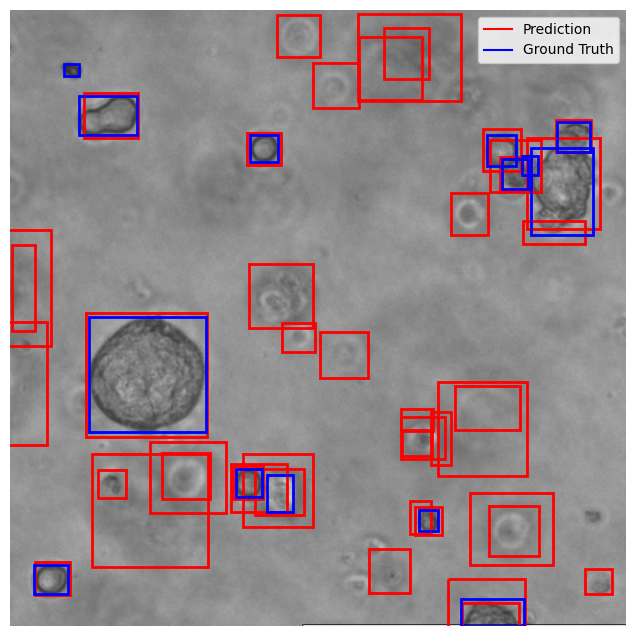

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import ast
import os

# Paths for the CSV file and ground truth folder
file_path = r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\results_yolov3.csv'
gt_folder = r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\test_multiorg\bboxs_all'

# Load the CSV file
df = pd.read_csv(file_path)

# Load the image
example_img = r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\test_multiorg\images_all\ACC2.png'
image = Image.open(example_img)

# Get the image filename (without extension) to match ground truth
image_name = os.path.splitext(os.path.basename(example_img))[0]
gt_path = os.path.join(gt_folder, f"{image_name}.npy")

# Extract the bounding boxes for predictions from the CSV (using ast.literal_eval for safety)
bbox_dict = ast.literal_eval(df.loc[1, 'Predicted Boxes'])
pred_bboxes = [coords[:4] for coords in bbox_dict.values()]

# Load ground truth bounding boxes from the .npy file
gt_bboxes = np.load(gt_path)

# Plot the image
plt.figure(figsize=(8, 8))
plt.imshow(image)

# Plot each predicted bounding box in red
for coords in pred_bboxes:
    x_min, y_min, x_max, y_max = coords
    width, height = x_max - x_min, y_max - y_min
    rect = plt.Rectangle((x_min, y_min), width, height, edgecolor='red', facecolor='none', linewidth=2, label='Prediction')
    plt.gca().add_patch(rect)

# Plot each ground truth bounding box in blue
for coords in gt_bboxes:
    x_min, y_min, x_max, y_max = coords
    width, height = x_max - x_min, y_max - y_min
    rect = plt.Rectangle((x_min, y_min), width, height, edgecolor='blue', facecolor='none', linewidth=2, label='Ground Truth')
    plt.gca().add_patch(rect)

# Show plot with axis off
plt.axis('off')
plt.legend(handles=[plt.Line2D([0], [0], color='red', label='Prediction'), plt.Line2D([0], [0], color='blue', label='Ground Truth')])
plt.show()


# Extract ground truth

In [25]:
import os
import numpy as np

# Define directories
gt_folder = r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\test_multiorg\segmentations_all'
bbox_folder = r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\test_multiorg\bboxs_all'

# Create the output directory if it doesn't exist
os.makedirs(bbox_folder, exist_ok=True)

# Iterate through all mask files in the ground truth folder
for filename in os.listdir(gt_folder):
    if filename.endswith('.npy'):  # Assuming mask files are in .npy format
        mask_path = os.path.join(gt_folder, filename)
        mask = np.load(mask_path)
        
        # Collect bounding boxes
        bboxes = []
        unique_labels = np.unique(mask)
        for label in unique_labels:
            if label == 0:
                continue  # Skip background
            mask_label = (mask == label).astype(np.uint8)
            coords = np.argwhere(mask_label)
            y_min, x_min = coords.min(axis=0)
            y_max, x_max = coords.max(axis=0)
            bboxes.append([x_min, y_min, x_max, y_max])
        
        # Save bounding boxes as npy file in bbox_folder
        bbox_path = os.path.join(bbox_folder, filename)
        np.save(bbox_path, np.array(bboxes))


# Metric value

In [50]:
import os
import numpy as np
import pandas as pd
import ast

# Define paths
gt_folder = r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\test_multiorg\bboxs_all'
result_faster_rcnn = r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\results_faster r-cnn.csv'
result_rtmdet = r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\results_rtmdet.csv'
result_yolov3 = r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\results_yolov3.csv'

output_folder = r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\metrics'
os.makedirs(output_folder, exist_ok=True)

# Function to calculate IoU
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)
    
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

# Function to evaluate metrics with score-based matching
def evaluate_metrics(gt_bboxes, pred_bboxes, iou_threshold=0.5):
    # Sort predicted boxes by score in descending order
    pred_bboxes = sorted(pred_bboxes, key=lambda x: x[1], reverse=True)  # Sort by score (second element in tuple)
    
    matches = []
    used_gt_indices = set()  # Track matched ground truth boxes
    ious = []

    for pred_box, _ in pred_bboxes:
        best_iou = 0
        best_gt_idx = -1
        for gt_idx, gt_box in enumerate(gt_bboxes):
            if gt_idx in used_gt_indices:
                continue
            iou = compute_iou(gt_box, pred_box)  # Only use coordinates for IoU
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx
        if best_iou >= iou_threshold and best_gt_idx != -1:
            matches.append(1)
            used_gt_indices.add(best_gt_idx)
            ious.append(best_iou)
        else:
            matches.append(0)

    mean_iou = np.mean(ious) if ious else 0
    recall = len(used_gt_indices) / len(gt_bboxes) if len(gt_bboxes) > 0 else 0
    precision = sum(matches) / len(pred_bboxes) if len(pred_bboxes) > 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return mean_iou, recall, precision, f1

# Load CSVs and ground truth
csv_paths = {
    'faster_rcnn': result_faster_rcnn,
    'rtmdet': result_rtmdet,
    'yolov3': result_yolov3
}

for model_name, csv_path in csv_paths.items():
    output_metrics = {'mean_iou': [], 'recall': [], 'precision': [], 'f1': []}
    predictions = pd.read_csv(csv_path)

    # Sort GT files
    gt_files = sorted(os.listdir(gt_folder))
    
    for idx, gt_file in enumerate(gt_files):
        gt_bboxes = np.load(os.path.join(gt_folder, gt_file))
        
        # Extract bounding boxes and scores from CSV
        bbox_dict = ast.literal_eval(predictions.loc[idx, 'Predicted Boxes'])
        score_dict = ast.literal_eval(predictions.loc[idx, 'Model scores'])

        # Pair each bbox with its score and create a list of tuples
        pred_bboxes = [(bbox, score_dict[i]) for i, bbox in bbox_dict.items()]

        # Evaluate metrics
        mean_iou, recall, precision, f1 = evaluate_metrics(gt_bboxes, pred_bboxes)
        output_metrics['mean_iou'].append(mean_iou)
        output_metrics['recall'].append(recall)
        output_metrics['precision'].append(precision)
        output_metrics['f1'].append(f1)

    # Save metrics
    model_output_folder = os.path.join(output_folder, model_name)
    os.makedirs(model_output_folder, exist_ok=True)
    np.save(os.path.join(model_output_folder, 'mean_iou.npy'), np.array(output_metrics['mean_iou']))
    np.save(os.path.join(model_output_folder, 'recall.npy'), np.array(output_metrics['recall']))
    np.save(os.path.join(model_output_folder, 'precision.npy'), np.array(output_metrics['precision']))
    np.save(os.path.join(model_output_folder, 'f1.npy'), np.array(output_metrics['f1']))


In [51]:
import os
import numpy as np
import pandas as pd

# Paths to the saved metrics
metric_paths = {
    'faster_rcnn': r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\metrics\faster_rcnn',
    'rtmdet': r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\metrics\rtmdet',
    'yolov3': r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\metrics\yolov3'
}

# Define output folder for CSVs
output_folder = r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\metrics_csv'
os.makedirs(output_folder, exist_ok=True)

# File order based on given list
file_order = [
    'ACC1.npy', 'ACC2.npy', 'ACC3.npy', 'ACC4.npy', 'ACC5.npy', 'ACC6.npy',
    'C1.npy', 'C2.npy', 'C3.npy', 'C4.npy', 'C5.npy', 'C6.npy',
    'Lung1.npy', 'Lung2.npy', 'Lung3.npy', 'Lung4.npy', 'Lung5.npy', 'Lung6.npy',
    'PDAC1.npy', 'PDAC10.npy', 'PDAC2.npy', 'PDAC3.npy', 'PDAC4.npy', 'PDAC5.npy',
    'PDAC6.npy', 'PDAC7.npy', 'PDAC8.npy', 'PDAC9.npy',
    'b_image0007.npy', 'b_image0009.npy', 'image0016.npy', 'image0017.npy'
]

# Define categories with their corresponding file indices based on the ordered list
categories = {
    "ACC": list(range(0, 6)),
    "C": list(range(6, 12)),
    "Lung": list(range(12, 18)),
    "PDAC": list(range(18, 28)),
    "Mouse": list(range(28, 32))
}

# Metrics to be processed
metrics = ['mean_iou', 'recall', 'precision', 'f1']
metrics_results = {metric: {cat: {} for cat in categories} for metric in metrics}

# Process each model's precomputed metrics
for model_name, model_path in metric_paths.items():
    print(model_name)
    for metric in metrics:
        print(metric)
        # Load the precomputed metric values for the model
        metric_values = np.load(os.path.join(model_path, f"{metric}.npy"))
        print(os.path.join(model_path, f"{metric}.npy"))

        # Process each category
        for category, indices in categories.items():
            print(category)
            # Extract metric values for the specified indices for each category
            category_metrics = [metric_values[i] for i in indices]
            print(indices)
            # Compute the mean metric value for the category
            metrics_results[metric][category][model_name] = np.mean(category_metrics)

# Convert the results to DataFrames and save each metric to a CSV file
for metric, data in metrics_results.items():
    df = pd.DataFrame(data).T
    df.to_csv(os.path.join(output_folder, f"{metric}.csv"))

print("CSV files saved successfully.")


faster_rcnn
mean_iou
C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\metrics\faster_rcnn\mean_iou.npy
ACC
[0, 1, 2, 3, 4, 5]
C
[6, 7, 8, 9, 10, 11]
Lung
[12, 13, 14, 15, 16, 17]
PDAC
[18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
Mouse
[28, 29, 30, 31]
recall
C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\metrics\faster_rcnn\recall.npy
ACC
[0, 1, 2, 3, 4, 5]
C
[6, 7, 8, 9, 10, 11]
Lung
[12, 13, 14, 15, 16, 17]
PDAC
[18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
Mouse
[28, 29, 30, 31]
precision
C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\metrics\faster_rcnn\precision.npy
ACC
[0, 1, 2, 3, 4, 5]
C
[6, 7, 8, 9, 10, 11]
Lung
[12, 13, 14, 15, 16, 17]
PDAC
[18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
Mouse
[28, 29, 30, 31]
f1
C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\multiorg\metrics\faster_rcnn\f1.npy
ACC
[0, 1, 2, 3, 4, 5]
C
[6, 7, 8, 9, 10, 11]
Lung
[12, 13, 14, 15, 16, 17]
PDAC
[18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
Mouse
[28, 29, 30, 31]
rtmdet